# Leveraging Graph Neural Networks to Uncover Illicit Financial Networks

## Executive Summary
Financial crimes, such as money laundering and fraud, are rarely isolated events; they are often driven by sophisticated rings utilizing complex network topologies to hide illicit funds. Traditional Machine Learning methods (like Random Forests or XGBoost) treat transactions as independent and identically distributed (I.I.D.), failing to capture the relational flow of money.

In this project, we move beyond tabular data to a holistic graph-based analysis. We use **Graph Neural Networks (GNNs)** on the Elliptic Dataset to detect illicit transactions by learning from both node-level features and the overall network structure.

---
### Environment Setup
Installing PyTorch Geometric and importing essential libraries for data manipulation, graph construction, and deep learning.

In [3]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-sparse  -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3877460 sha256=b1283a78caa8e1a0de912bf96ef74ba31f39d88950e4b4bd3020e62525b44277
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch-scatter
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 5.5 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=3120327 sha256=7f8f68dec96796b07ab05e226671b1f639a380102e4fde201a9079dde7e9aba5
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd1d78ce1629aec4ecc924a63b82f6949dda484b6321eac6f2
Successfully built to

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, precision_recall_curve, auc
)
from xgboost import XGBClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.explain import Explainer, GNNExplainer
RANDOM_SEED = 7
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')
print(f'PyTorch version : {torch.__version__}')

Using device    : cuda
PyTorch version : 2.10.0+cu128


## 1. Dataset Loading & Overview
We are using the **Elliptic Dataset**, a graph network of cryptocurrency transactions. The dataset consists of three main components:
1. **Features Matrix:** The attributes associated with each transaction.
2. **Edge List:** The directed graph of money flowing from one transaction to another.
3. **Classes:** The label of the transaction (`1` for Illicit, `0` for Licit, and `1` for unlabeled).

In [5]:
raw_feats  = pd.read_csv('/kaggle/input/datasets/shivambansal1021/elliptic-dataset/elliptic_txs_features.csv', header=None)
raw_edges  = pd.read_csv('/kaggle/input/datasets/shivambansal1021/elliptic-dataset/elliptic_txs_edgelist.csv')
raw_labels = pd.read_csv('/kaggle/input/datasets/shivambansal1021/elliptic-dataset/elliptic_txs_classes.csv')

print('File Shapes:')
print(f'  Features matrix : {raw_feats.shape}')
print(f'  Edge list       : {raw_edges.shape}')
print(f'  Labels          : {raw_labels.shape}')

File Shapes:
  Features matrix : (203769, 167)
  Edge list       : (234355, 2)
  Labels          : (203769, 2)


## 2. Exploratory Data Analysis & Feature Highlights

Understanding the features is critical to detecting adversarial networks. The dataset contains **166 features** per transaction:
* **94 Local Features:** Include transaction-specific metrics such as the fee, volume, and number of inputs/outputs.
* **72 Aggregated Features:** Describe the neighborhood (one-hop away) of the transaction, such as the maximum/minimum fee of neighbors, providing early structural context.

**The Class Imbalance Problem:**
As shown in the charts below, illicit transactions make up an extremely small fraction (~2%) of the labeled data. Because of this extreme class imbalance, standard accuracy is an invalid metric. We will rely on **Macro F1-Score** and **PR-AUC** to evaluate our models.

In [6]:
FEAT_NAMES = ['tx_id', 'timestep'] + [f'feat_{k}' for k in range(1, 166)]
raw_feats.columns  = FEAT_NAMES
raw_labels.columns = ['tx_id', 'class_label']
print('Class Label Counts:')
print(raw_labels['class_label'].value_counts())
print('\nClass Proportions (%):')
print(raw_labels['class_label'].value_counts(normalize=True).mul(100).round(2))

Class Label Counts:
class_label
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Class Proportions (%):
class_label
unknown    77.15
2          20.62
1           2.23
Name: proportion, dtype: float64


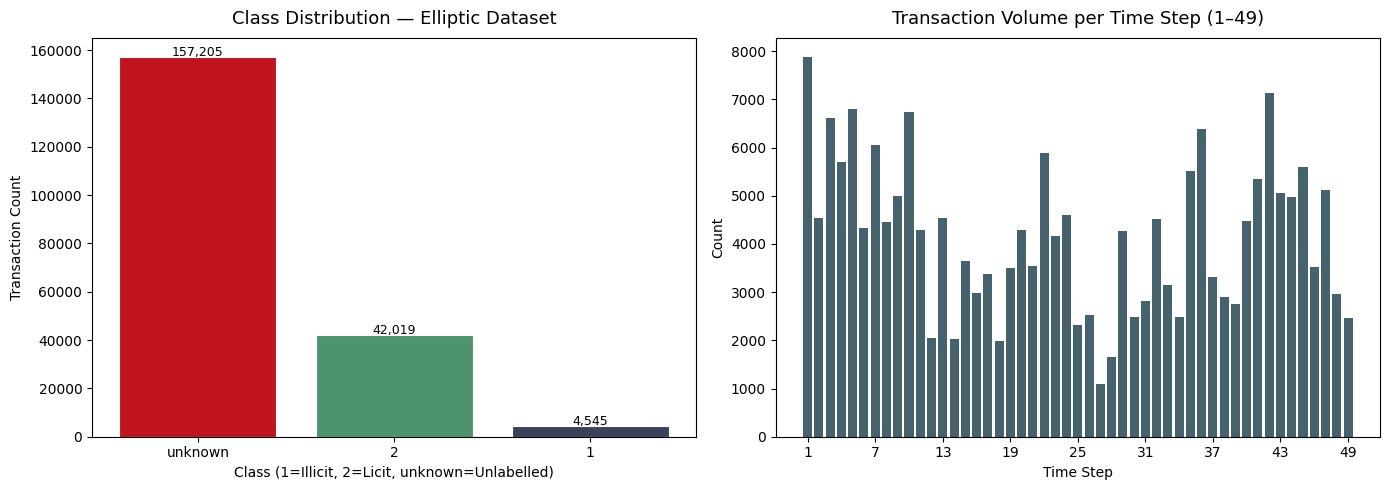

In [7]:
PALETTE = ['#C1121F', '#4C956C', '#3D405B']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
class_counts = raw_labels['class_label'].value_counts()
bars = ax1.bar(class_counts.index, class_counts.values,
               color=PALETTE, edgecolor='white', linewidth=0.8)
ax1.set_title('Class Distribution — Elliptic Dataset', fontsize=13, pad=10)
ax1.set_xlabel('Class (1=Illicit, 2=Licit, unknown=Unlabelled)')
ax1.set_ylabel('Transaction Count')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)

ts_dist = raw_feats['timestep'].value_counts().sort_index()
ax2.bar(ts_dist.index, ts_dist.values, color='#264653', alpha=0.85)
ax2.set_title('Transaction Volume per Time Step (1–49)', fontsize=13, pad=10)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Count')
ax2.set_xticks(range(1, 50, 6))

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
print('Feature matrix — first 5 rows, first 6 columns:')
print(raw_feats.iloc[:5, :6].to_string())
print()
print('Feature breakdown:')
print('  Columns 1  (tx_id)     — unique transaction ID')
print('  Column  2  (timestep)  — which 2-week period this tx occurred in')
print('  Columns 3-95 (feat_1..feat_93)  — 93 LOCAL features (fee, volume, etc.)')
print('  Columns 96-167 (feat_94..feat_165) — 72 AGGREGATED neighbourhood features')

Feature matrix — first 5 rows, first 6 columns:
       tx_id  timestep    feat_1    feat_2    feat_3     feat_4
0  230425980         1 -0.171469 -0.184668 -1.201369  -0.121970
1    5530458         1 -0.171484 -0.184668 -1.201369  -0.121970
2  232022460         1 -0.172107 -0.184668 -1.201369  -0.121970
3  232438397         1  0.163054  1.963790 -0.646376  12.409294
4  230460314         1  1.011523 -0.081127 -1.201369   1.153668

Feature breakdown:
  Columns 1  (tx_id)     — unique transaction ID
  Column  2  (timestep)  — which 2-week period this tx occurred in
  Columns 3-95 (feat_1..feat_93)  — 93 LOCAL features (fee, volume, etc.)
  Columns 96-167 (feat_94..feat_165) — 72 AGGREGATED neighbourhood features


## 3. Data Preprocessing & Graph Construction

To feed this data into a GNN, we must process the tabular structures into a cohesive PyTorch Geometric `Data` object. The steps include:
1. **Label Encoding:** Converting the string classes to numeric values (`1` = illicit, `0` = licit, `-1` = unknown).
2. **Node Mapping:** Re-indexing the raw transaction IDs into continuous integer representations so PyTorch can efficiently map edges to feature matrices.
3. **Feature Scaling:** Applying `StandardScaler` to normalize the local and aggregated features, which ensures stable and faster convergence during neural network training.

In [9]:
df = raw_feats.merge(raw_labels, on='tx_id', how='left')

LABEL_ENCODING = {'1': 1, '2': 0, 'unknown': -1}
df['encoded_y'] = df['class_label'].map(LABEL_ENCODING)

print('Encoded label distribution:')
print(df['encoded_y'].value_counts())

Encoded label distribution:
encoded_y
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [10]:
tx_ids      = df['tx_id'].values
txid_map    = {txid: i for i, txid in enumerate(tx_ids)}
print(f'Total graph nodes : {len(txid_map):,}')

Total graph nodes : 203,769


In [11]:
feat_cols = ['timestep'] + [f'feat_{k}' for k in range(1, 166)]
X_raw     = df[feat_cols].values.astype(np.float32)

scaler = StandardScaler()
X_std  = scaler.fit_transform(X_raw)
print(f'Normalised feature matrix shape: {X_std.shape}')

Normalised feature matrix shape: (203769, 166)


In [12]:
src = raw_edges['txId1'].map(txid_map).dropna().astype(int).values
dst = raw_edges['txId2'].map(txid_map).dropna().astype(int).values

edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f'Edge index shape: {edge_index.shape}')

Edge index shape: torch.Size([2, 234355])


### Creating Train, Validation, and Test Masks
Unlike traditional ML where we split rows, in Graph Learning, the graph remains intact to preserve connectivity, and we use **boolean masks** to hide labels during training. 

We only generate masks for the nodes with known labels. We use a stratified split (70% Train, 15% Validation, 15% Test) to ensure the highly imbalanced minority class (illicit transactions) is proportionately represented in all subsets.

In [13]:
y_tensor  = torch.tensor(df['encoded_y'].values, dtype=torch.long)

labeled_mask    = y_tensor != -1
labeled_indices = labeled_mask.nonzero(as_tuple=True)[0].numpy()
labeled_ys      = y_tensor[labeled_indices].numpy()

train_ids, hold_ids = train_test_split(
    labeled_indices, test_size=0.30, stratify=labeled_ys, random_state=RANDOM_SEED
)
hold_ys = labeled_ys[np.isin(labeled_indices, hold_ids)]
val_ids, test_ids = train_test_split(
    hold_ids, test_size=0.50, stratify=hold_ys, random_state=RANDOM_SEED
)

N = len(df)
tr_mask  = torch.zeros(N, dtype=torch.bool)
val_mask = torch.zeros(N, dtype=torch.bool)
te_mask  = torch.zeros(N, dtype=torch.bool)
tr_mask[train_ids] = True
val_mask[val_ids]  = True
te_mask[test_ids]  = True

print(f'Partition sizes — Train: {tr_mask.sum()} | Val: {val_mask.sum()} | Test: {te_mask.sum()}')

Partition sizes — Train: 32594 | Val: 6985 | Test: 6985


In [14]:
graph = Data(
    x          = torch.tensor(X_std, dtype=torch.float),
    edge_index = edge_index,
    y          = y_tensor,
    train_mask = tr_mask,
    val_mask   = val_mask,
    test_mask  = te_mask,
).to(DEVICE)

print('Graph object summary:')
print(graph)

Graph object summary:
Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


## 4. Model Architectures & Loss Optimization

We will test and compare three different GNN architectures to capture the relational data underlying the financial system:
1. **Graph Convolutional Networks (GCN):** A baseline spectral approach that averages neighborhood features.
2. **GraphSAGE:** Uses neighborhood sampling, making it highly scalable and capable of inductive learning.
3. **Graph Attention Networks (GAT):** Dynamically assigns different importance weights to different neighbors, allowing the model to focus heavily on suspicious connections while ignoring benign ones.

**Loss Optimization (Focal Loss):**
Because illicit transactions are incredibly rare, standard Cross-Entropy loss would result in the model predicting everything as "licit". We implement **Focal Loss** to penalize the model heavily for missing the minority class.

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        per_sample_ce = F.cross_entropy(logits, targets, reduction='none')
        prob_correct  = torch.exp(-per_sample_ce)            # p_t
        focal_weight  = (1.0 - prob_correct) ** self.gamma
        return (self.alpha * focal_weight * per_sample_ce).mean()

### Model 1: Graph Convolutional Network (GCN)

In [16]:
class GCNModel(nn.Module):

    def __init__(self, n_input: int, n_hidden: int, n_classes: int,
                 drop_rate: float = 0.45):
        super().__init__()
        self.conv_in  = GCNConv(n_input,  n_hidden)
        self.conv_mid = GCNConv(n_hidden, n_hidden)
        self.conv_out = GCNConv(n_hidden, n_classes)
        self.drop_rate = drop_rate

    def forward(self, node_feats, edges):
        h = F.relu(self.conv_in(node_feats, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        h = F.relu(self.conv_mid(h, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        return self.conv_out(h, edges)   # returns raw logits

### Model 2: GraphSAGE

In [17]:
class SAGEModel(nn.Module):

    def __init__(self, n_input: int, n_hidden: int, n_classes: int,
                 drop_rate: float = 0.45):
        super().__init__()
        self.sage_in  = SAGEConv(n_input,  n_hidden)
        self.sage_mid = SAGEConv(n_hidden, n_hidden)
        self.sage_out = SAGEConv(n_hidden, n_classes)
        self.drop_rate = drop_rate

    def forward(self, node_feats, edges):
        h = F.relu(self.sage_in(node_feats, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        h = F.relu(self.sage_mid(h, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        return self.sage_out(h, edges)

### Model 3: Graph Attention Network (GAT)

In [18]:
class GATModel(nn.Module):

    def __init__(self, n_input: int, n_hidden: int, n_classes: int,
                 num_heads: int = 4, drop_rate: float = 0.45):
        super().__init__()
        self.gat1 = GATConv(n_input,           n_hidden,
                            heads=num_heads, concat=True,  dropout=drop_rate)
        self.gat2 = GATConv(n_hidden * num_heads, n_hidden,
                            heads=num_heads, concat=True,  dropout=drop_rate)
        self.gat3 = GATConv(n_hidden * num_heads, n_classes,
                            heads=1,         concat=False, dropout=drop_rate)
        self.drop_rate = drop_rate

    def forward(self, node_feats, edges):
        h = F.elu(self.gat1(node_feats, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        h = F.elu(self.gat2(h, edges))
        h = F.dropout(h, p=self.drop_rate, training=self.training)
        return self.gat3(h, edges)

## 5. Training Infrastructure & Evaluation Metrics

We define our training loop and scoring function here. Given the business context of reducing operational costs for fraud investigation teams, we evaluate the models using:
* **Primary Technical Metrics:** Area Under the Precision-Recall Curve (PR-AUC) and Macro F1-Score.
* **Recall on Minority Class:** Catching actual illicit transactions is prioritized over sheer accuracy.

In [19]:
def run_train_step(model, g, opt, loss_fn):
    model.train()
    opt.zero_grad()
    out  = model(g.x, g.edge_index)
    loss = loss_fn(out[g.train_mask], g.y[g.train_mask])
    loss.backward()
    opt.step()
    return loss.item()


@torch.no_grad()
def score_model(model, g, partition_mask):
    model.eval()
    logits  = model(g.x, g.edge_index)
    p_illicit  = F.softmax(logits[partition_mask], dim=-1)[:, 1].cpu().numpy()
    pred_cls   = logits[partition_mask].argmax(dim=-1).cpu().numpy()
    true_cls   = g.y[partition_mask].cpu().numpy()

    mf1  = f1_score(true_cls, pred_cls, average='macro', zero_division=0)
    prec, rec, _ = precision_recall_curve(true_cls, p_illicit, pos_label=1)
    prauc = auc(rec, prec)

    return mf1, prauc, pred_cls, true_cls, p_illicit


def run_full_training(model, g, n_epochs=200,
                      learning_rate=5e-3, l2_reg=5e-4):
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    optimiser = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=l2_reg
    )
    lr_sched = torch.optim.lr_scheduler.StepLR(
        optimiser, step_size=50, gamma=0.5
    )

    history   = {'train_loss': [], 'val_f1': [], 'val_pr_auc': []}
    top_val_f1     = 0.0
    saved_weights  = None

    for epoch in range(1, n_epochs + 1):
        loss      = run_train_step(model, g, optimiser, criterion)
        v_f1, v_pr, *_ = score_model(model, g, g.val_mask)
        lr_sched.step()

        history['train_loss'].append(loss)
        history['val_f1'].append(v_f1)
        history['val_pr_auc'].append(v_pr)

        if v_f1 > top_val_f1:
            top_val_f1    = v_f1
            saved_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f'  Epoch {epoch:>3}  loss={loss:.4f}  '
                  f'val-F1={v_f1:.4f}  val-PRAUC={v_pr:.4f}')

    model.load_state_dict(saved_weights)  # restore best checkpoint
    print(f'\n  Best Validation Macro-F1: {top_val_f1:.4f}')
    return history

## Train GCN, GraphSAGE, and GAT

In [20]:
INPUT_DIM  = graph.num_node_features   # 166
HIDDEN_DIM = 128
OUTPUT_DIM = 2                          # licit vs illicit

# GCN
print('  Training GCN  (Graph Convolutional Network)')
gcn_model    = GCNModel(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
gcn_history  = run_full_training(gcn_model, graph, n_epochs=200)

# GraphSAGE
print('\n')
print('  Training GraphSAGE  (Inductive Learning)')
sage_model   = SAGEModel(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
sage_history = run_full_training(sage_model, graph, n_epochs=200)

# GAT
print('\n')
print('  Training GAT  (Graph Attention Network)')
gat_model    = GATModel(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, num_heads=4).to(DEVICE)
gat_history  = run_full_training(gat_model, graph, n_epochs=200)

  Training GCN  (Graph Convolutional Network)
  Epoch  20  loss=0.0177  val-F1=0.5400  val-PRAUC=0.5201
  Epoch  40  loss=0.0138  val-F1=0.7518  val-PRAUC=0.6655
  Epoch  60  loss=0.0127  val-F1=0.7771  val-PRAUC=0.6912
  Epoch  80  loss=0.0120  val-F1=0.7863  val-PRAUC=0.7078
  Epoch 100  loss=0.0116  val-F1=0.7994  val-PRAUC=0.7263
  Epoch 120  loss=0.0114  val-F1=0.8039  val-PRAUC=0.7318
  Epoch 140  loss=0.0110  val-F1=0.8171  val-PRAUC=0.7394
  Epoch 160  loss=0.0109  val-F1=0.8134  val-PRAUC=0.7448
  Epoch 180  loss=0.0108  val-F1=0.8173  val-PRAUC=0.7490
  Epoch 200  loss=0.0105  val-F1=0.8210  val-PRAUC=0.7525

  Best Validation Macro-F1: 0.8210


  Training GraphSAGE  (Inductive Learning)
  Epoch  20  loss=0.0119  val-F1=0.7975  val-PRAUC=0.7656
  Epoch  40  loss=0.0087  val-F1=0.8858  val-PRAUC=0.8871
  Epoch  60  loss=0.0074  val-F1=0.9064  val-PRAUC=0.9022
  Epoch  80  loss=0.0068  val-F1=0.9151  val-PRAUC=0.9126
  Epoch 100  loss=0.0063  val-F1=0.9180  val-PRAUC=0.9188
  E

### Learning Curves

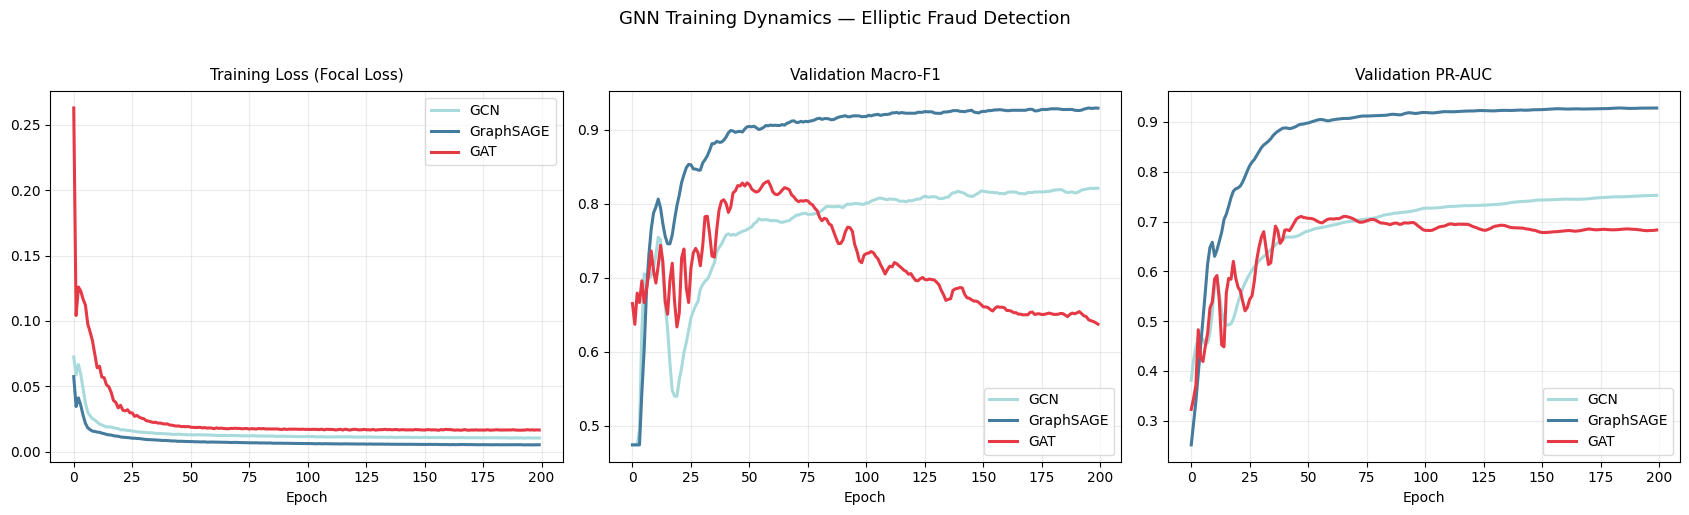

In [21]:
MODEL_RESULTS = {
    'GCN':       (gcn_history,  '#A8DADC'),
    'GraphSAGE': (sage_history, '#457B9D'),
    'GAT':       (gat_history,  '#E63946'),
}

CURVE_TITLES = {
    'train_loss': 'Training Loss (Focal Loss)',
    'val_f1':     'Validation Macro-F1',
    'val_pr_auc': 'Validation PR-AUC',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (metric_key, title) in zip(axes, CURVE_TITLES.items()):
    for model_name, (hist, color) in MODEL_RESULTS.items():
        ax.plot(hist[metric_key], label=model_name,
                color=color, linewidth=2.2)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('Epoch')
    ax.legend(framealpha=0.7)
    ax.grid(alpha=0.25)

fig.suptitle('GNN Training Dynamics — Elliptic Fraud Detection',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

## Test Set Evaluation

  GCN  —  Test Set Results
  Macro-F1   : 0.8180
  PR-AUC     : 0.7712

Classification Report:
              precision    recall  f1-score   support

       Licit       0.95      0.99      0.97      6306
     Illicit       0.83      0.56      0.67       679

    accuracy                           0.95      6985
   macro avg       0.89      0.77      0.82      6985
weighted avg       0.94      0.95      0.94      6985



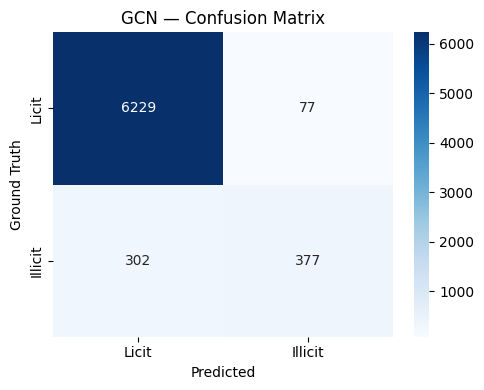

  GraphSAGE  —  Test Set Results
  Macro-F1   : 0.9238
  PR-AUC     : 0.9308

Classification Report:
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99      6306
     Illicit       0.95      0.78      0.86       679

    accuracy                           0.98      6985
   macro avg       0.97      0.89      0.92      6985
weighted avg       0.97      0.98      0.97      6985



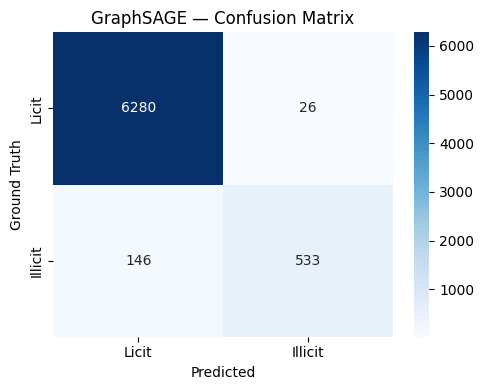

  GAT  —  Test Set Results
  Macro-F1   : 0.8227
  PR-AUC     : 0.6898

Classification Report:
              precision    recall  f1-score   support

       Licit       0.96      0.98      0.97      6306
     Illicit       0.74      0.63      0.68       679

    accuracy                           0.94      6985
   macro avg       0.85      0.80      0.82      6985
weighted avg       0.94      0.94      0.94      6985



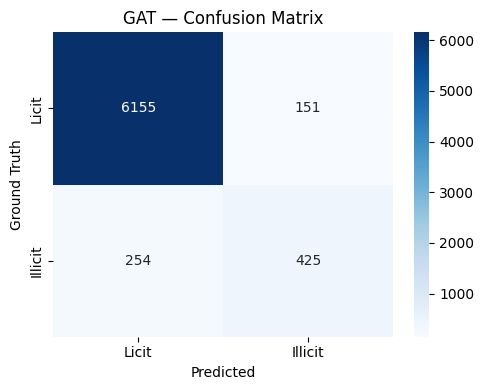

In [22]:
def full_evaluation(model, label, g):
    f1, prauc, preds, truth, _ = score_model(model, g, g.test_mask)

    print(f'  {label}  —  Test Set Results')
    print(f'  Macro-F1   : {f1:.4f}')
    print(f'  PR-AUC     : {prauc:.4f}')
    print('\nClassification Report:')
    print(classification_report(truth, preds,
                                target_names=['Licit', 'Illicit'],
                                zero_division=0))

    cm = confusion_matrix(truth, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Licit', 'Illicit'],
                yticklabels=['Licit', 'Illicit'], ax=ax)
    ax.set_title(f'{label} — Confusion Matrix')
    ax.set_ylabel('Ground Truth')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return f1, prauc


gcn_f1,  gcn_prauc  = full_evaluation(gcn_model,  'GCN',       graph)
sage_f1, sage_prauc = full_evaluation(sage_model, 'GraphSAGE', graph)
gat_f1,  gat_prauc  = full_evaluation(gat_model,  'GAT',       graph)

## XGBoost Baseline

In [23]:
X_np = graph.x.cpu().numpy()
y_np = graph.y.cpu().numpy()

X_train_xgb = X_np[tr_mask.cpu()];  y_train_xgb = y_np[tr_mask.cpu()]
X_test_xgb  = X_np[te_mask.cpu()];  y_test_xgb  = y_np[te_mask.cpu()]

class_ratio = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    scale_pos_weight  = class_ratio,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = RANDOM_SEED,
)
xgb.fit(X_train_xgb, y_train_xgb)

xgb_preds  = xgb.predict(X_test_xgb)
xgb_probs  = xgb.predict_proba(X_test_xgb)[:, 1]
xgb_f1     = f1_score(y_test_xgb, xgb_preds, average='macro')
p_, r_, _  = precision_recall_curve(y_test_xgb, xgb_probs, pos_label=1)
xgb_prauc  = auc(r_, p_)

print(f'XGBoost (Baseline)  |  Macro-F1: {xgb_f1:.4f}  |  PR-AUC: {xgb_prauc:.4f}')
print()
print(classification_report(y_test_xgb, xgb_preds,
                             target_names=['Licit', 'Illicit']))

XGBoost (Baseline)  |  Macro-F1: 0.9770  |  PR-AUC: 0.9858

              precision    recall  f1-score   support

       Licit       0.99      1.00      1.00      6306
     Illicit       0.99      0.93      0.96       679

    accuracy                           0.99      6985
   macro avg       0.99      0.96      0.98      6985
weighted avg       0.99      0.99      0.99      6985



## Summary Comparison Table & Bar Charts

Final Model Comparison:
            Model  Macro F1   PR-AUC
XGBoost (Tabular)  0.976977 0.985844
        GraphSAGE  0.923778 0.930801
              GAT  0.822719 0.689773
              GCN  0.817983 0.771209


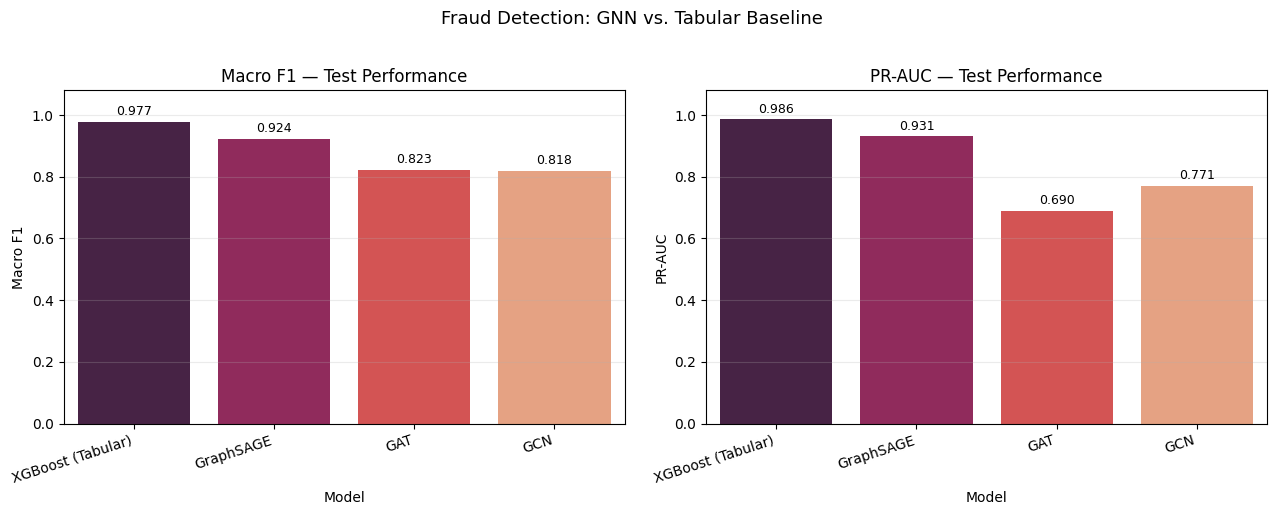

In [24]:
results_df = pd.DataFrame({
    'Model':   ['XGBoost (Tabular)', 'GCN', 'GraphSAGE', 'GAT'],
    'Macro F1': [xgb_f1,  gcn_f1,  sage_f1,  gat_f1],
    'PR-AUC':   [xgb_prauc, gcn_prauc, sage_prauc, gat_prauc],
})
results_df = results_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('Final Model Comparison:')
print(results_df.to_string(index=False))

# ── Side-by-side bar charts ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in [(ax1, 'Macro F1'), (ax2, 'PR-AUC')]:
    sns.barplot(data=results_df, x='Model', y=metric,
                palette='rocket', ax=ax)
    ax.set_ylim(0, 1.08)
    ax.set_title(f'{metric} — Test Performance', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha='right')
    ax.grid(axis='y', alpha=0.25)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

fig.suptitle('Fraud Detection: GNN vs. Tabular Baseline',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## GNNExplainer

In [25]:
explainer = Explainer(
    model             = sage_model,
    algorithm         = GNNExplainer(epochs=200),
    explanation_type  = 'model',
    node_mask_type    = 'attributes',
    edge_mask_type    = 'object',
    model_config = dict(
        mode        = 'multiclass_classification',
        task_level  = 'node',
        return_type = 'log_probs',
    ),
)

_, _, te_preds, _, _ = score_model(sage_model, graph, graph.test_mask)
test_node_indices    = graph.test_mask.nonzero(as_tuple=True)[0].cpu().numpy()
illicit_nodes        = test_node_indices[te_preds == 1]

explain_target = int(illicit_nodes[0])
print(f'Explaining node: {explain_target}')

expl = explainer(graph.x, graph.edge_index, index=explain_target)
print(f'Node mask shape : {expl.node_mask.shape}')
print(f'Edge mask shape : {expl.edge_mask.shape}')

Explaining node: 36965
Node mask shape : torch.Size([203769, 166])
Edge mask shape : torch.Size([234355])



Top 10 features driving fraud prediction for node 36965:
#     Feature        Score     
──────────────────────────────
1     feat_113       0.7474
2     feat_149       0.7424
3     feat_53        0.7322
4     feat_55        0.7318
5     feat_90        0.7278
6     feat_52        0.7204
7     feat_89        0.7063
8     feat_137       0.6296
9     feat_155       0.6230
10    feat_154       0.5568


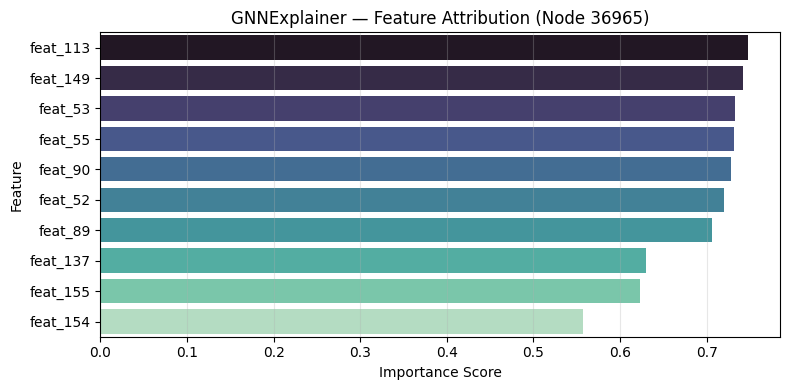

In [26]:
importance_scores = expl.node_mask[explain_target].cpu().numpy()
top10_indices     = np.argsort(importance_scores)[-10:][::-1]

print(f'\nTop 10 features driving fraud prediction for node {explain_target}:')
print(f'{"#":<5} {"Feature":<14} {"Score":<10}')
print('─' * 30)
for rank, fi in enumerate(top10_indices, 1):
    col_name = FEAT_NAMES[fi + 1]   # +1 because tx_id is at index 0
    print(f'{rank:<5} {col_name:<14} {importance_scores[fi]:.4f}')

top10_scores = importance_scores[top10_indices]
top10_labels = [FEAT_NAMES[i + 1] for i in top10_indices]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=top10_scores, y=top10_labels, palette='mako', ax=ax)
ax.set_title(f'GNNExplainer — Feature Attribution (Node {explain_target})')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_attribution.png', dpi=120)
plt.show()

## Scalability

In [27]:
X_local = graph.x[:, :94]

graph_reduced = Data(
    x          = X_local,
    edge_index = graph.edge_index,
    y          = graph.y,
    train_mask = graph.train_mask,
    val_mask   = graph.val_mask,
    test_mask  = graph.test_mask,
).to(DEVICE)

print('Training GraphSAGE — LOCAL FEATURES ONLY (94 dims):')
sage_ablation   = SAGEModel(94, HIDDEN_DIM, OUTPUT_DIM).to(DEVICE)
ablation_hist   = run_full_training(sage_ablation, graph_reduced, n_epochs=200)

ab_f1, ab_prauc, *_ = score_model(sage_ablation, graph_reduced, graph_reduced.test_mask)

print('\n')
print('  Ablation Study — Results')
print(f'  GraphSAGE (local only, 94 feats)  →  F1: {ab_f1:.4f}  PR-AUC: {ab_prauc:.4f}')
print(f'  GraphSAGE (full, 166 feats)       →  F1: {sage_f1:.4f}  PR-AUC: {sage_prauc:.4f}')
gap = sage_f1 - ab_f1
print(f'\n  Performance gap: ΔF1 = {gap:.4f}')
conclusion = (
    '  GNN learns structure from graph topology — hand-crafted features add little!'
    if abs(gap) < 0.02 else
    '  Moderate gap — hand-crafted features still add complementary signal.'
)
print(conclusion)

Training GraphSAGE — LOCAL FEATURES ONLY (94 dims):
  Epoch  20  loss=0.0156  val-F1=0.4742  val-PRAUC=0.5790
  Epoch  40  loss=0.0114  val-F1=0.6311  val-PRAUC=0.8223
  Epoch  60  loss=0.0104  val-F1=0.7686  val-PRAUC=0.8460
  Epoch  80  loss=0.0098  val-F1=0.8379  val-PRAUC=0.8582
  Epoch 100  loss=0.0092  val-F1=0.8755  val-PRAUC=0.8676
  Epoch 120  loss=0.0090  val-F1=0.8829  val-PRAUC=0.8725
  Epoch 140  loss=0.0088  val-F1=0.8867  val-PRAUC=0.8752
  Epoch 160  loss=0.0085  val-F1=0.8877  val-PRAUC=0.8779
  Epoch 180  loss=0.0084  val-F1=0.8930  val-PRAUC=0.8795
  Epoch 200  loss=0.0083  val-F1=0.8946  val-PRAUC=0.8810

  Best Validation Macro-F1: 0.8957


  Ablation Study — Results
  GraphSAGE (local only, 94 feats)  →  F1: 0.9029  PR-AUC: 0.8875
  GraphSAGE (full, 166 feats)       →  F1: 0.9238  PR-AUC: 0.9308

  Performance gap: ΔF1 = 0.0209
  Moderate gap — hand-crafted features still add complementary signal.
